In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, silhouette_score
from sklearn.preprocessing import StandardScaler

In [17]:
iris = load_iris()
X = iris.data[:,:2]
y = iris.target

In [18]:
df = pd.DataFrame(X, columns = ['sepal length (cm)','sepal width (cm)'])
print(df.head())

   sepal length (cm)  sepal width (cm)
0                5.1               3.5
1                4.9               3.0
2                4.7               3.2
3                4.6               3.1
4                5.0               3.6


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 5
kmeans = KMeans(n_clusters = k, random_state = 45)
cluster = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, cluster)
print("Silhouette Score: ", sil_score)

print("Cluster Centers: ")
print(kmeans.cluster_centers_)

Silhouette Score:  0.33720780670042827
Cluster Centers: 
[[ 1.02454166  0.66092049]
 [ 1.1037816  -0.28982869]
 [-1.24554357  0.28414544]
 [-0.71892936  1.53694708]
 [-0.15820571 -0.97929949]]


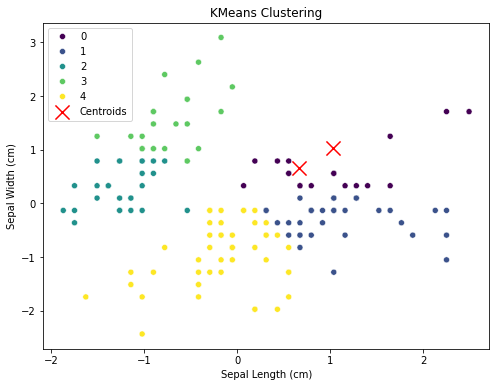

In [20]:
plt.figure(figsize = (8,6))
sns.scatterplot(x = X_scaled[:,0], y=X_scaled[:,1], hue=cluster, palette = 'viridis')
plt.scatter(kmeans.cluster_centers_[:1], kmeans.cluster_centers_[:1], color='red', marker = 'x', s=200, label='Centroids')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title("KMeans Clustering")
plt.legend()
plt.show()

In [22]:
new_sample = [[5.5, 7.2]]
new_sample_scaled = scaler.transform(new_sample)
predicted_clusters = KMeans(new_sample_scaled)
print("New Sample Class: ", predicted_clusters)

New Sample Class:  KMeans(n_clusters=array([[-0.41600969,  9.5362847 ]]))
